<a href="https://colab.research.google.com/github/yiding2022/DAAI/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn import preprocessing
from sklearn.metrics import pairwise
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
import matplotlib.pylab as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

Data

In [ ]:
# The data set gives corporate data on 22 public utilities in the United States (the
# variable definitions are given in the table footnote). We are interested in
# forming groups of similar utilities. The records to be clustered are the
# utilities, and the clustering will be based on the eight measurements on each
# utility. An example where clustering would be useful is a study to predict the
# cost impact of deregulation. To do the requisite analysis, economists would
# need to build a detailed cost model of the various utilities. It would save a
# considerable amount of time and effort if we could cluster similar types of
# utilities and build detailed cost models for just one “typical” utility in each
# cluster and then scale up from these models to estimate results for all utilities.

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

# Extract the file name
file_name = list(uploaded.keys())[0]

# Load the file into a Pandas DataFrame
utilities_df = pd.read_csv(file_name)

Saving Utilities.txt to Utilities.txt


In [ ]:
url = "https://raw.githubusercontent.com/yiding2022/DAAI/main/Utilities.txt"
utilities_df = pd.read_csv(url)

Hierarchical Clustering

In [ ]:
utilities_df

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044
5,Florida,1.32,13.5,111,60.0,-2.2,11127,22.5,1.241
6,Hawaiian,1.22,12.2,175,67.6,2.2,7642,0.0,1.652
7,Idaho,1.10,9.2,245,57.0,3.3,13082,0.0,0.309
8,Kentucky,1.34,13.0,168,60.4,7.2,8406,0.0,0.862
9,Madison,1.12,12.4,197,53.0,2.7,6455,39.2,0.623


In [ ]:
# Fixed = fixed-charge covering ratio (income/debt); RoR = rate of return on
# capital
# Cost = cost per kilowatt capacity in place; Load = annual load factor
# Demand = peak kilowatthour demand growth from 1974 to 1975
# Sales = sales (kilowatthour use per year)
# Nuclear = percent nuclear
# Fuel Cost = total fuel costs (cents per kilowatthour)

In [ ]:
# set row names to the utilities column
utilities_df.set_index('Company', inplace=True)
# while not required, the conversion of integer data to float
# will avoid a warning when applying the scale function
utilities_df = utilities_df.apply(lambda x: x.astype('float64'))

# compute Euclidean distance
d = pairwise.pairwise_distances(utilities_df, metric='euclidean')
pd.DataFrame(d, columns=utilities_df.index, index=utilities_df.index)

Company,Arizona,Boston,Central,Commonwealth,NY,Florida,Hawaiian,Idaho,Kentucky,Madison,...,Northern,Oklahoma,Pacific,Puget,San Diego,Southern,Texas,Wisconsin,United,Virginia
Company,,,,,,,,,,,,,,,,,,,,,
Arizona,0.000000,3989.408076,140.402855,2654.277632,5777.167672,2050.529440,1435.265019,4006.104187,671.276346,2622.699002,...,1899.279821,598.556633,2609.045363,6914.742065,3363.061626,1063.009074,4430.251585,1790.485648,2427.588875,1016.617691
Boston,3989.408076,0.000000,4125.044132,1335.466502,1788.068027,6039.689076,2554.287162,7994.155985,3318.276558,1367.090634,...,2091.160485,4586.302564,1380.749962,10903.146464,629.760748,5052.331669,8419.610541,2199.721665,1562.210811,5005.081262
Central,140.402855,4125.044132,0.000000,2789.759674,5912.552908,1915.155154,1571.295401,3872.257626,807.920792,2758.559663,...,2035.441520,461.341670,2744.502847,6780.430307,3498.113013,928.749249,4295.014690,1925.772564,2563.637362,883.535455
Commonwealth,2654.277632,1335.466502,2789.759674,0.000000,3123.153215,4704.363099,1219.560005,6659.534567,1983.314354,43.648894,...,756.831954,3250.984589,56.644626,9568.434429,710.292965,3717.202963,7084.372839,864.273153,232.476871,3670.018191
NY,5777.167672,1788.068027,5912.552908,3123.153215,0.000000,7827.429211,4342.093798,9782.158178,5106.094153,3155.095594,...,3879.167462,6373.743249,3168.177463,12691.155108,2414.698757,6840.150291,10207.392630,3987.335962,3350.073118,6793.035300
Florida,2050.529440,6039.689076,1915.155154,4704.363099,7827.429211,0.000000,3485.671562,1959.731080,2721.706296,4672.829286,...,3949.092316,1454.292604,4659.356262,4866.111649,5413.093004,988.044559,2380.124974,3840.227943,4478.028874,1035.981475
Hawaiian,1435.265019,2554.287162,1571.295401,1219.560005,4342.093798,3485.671562,0.000000,5440.461781,764.083188,1187.941143,...,466.559118,2032.614245,1174.075616,8349.366438,1928.441480,2498.149024,5865.447190,358.476293,992.453252,2451.185161
Idaho,4006.104187,7994.155985,3872.257626,6659.534567,9782.158178,1959.731080,5440.461781,0.000000,4676.638384,6627.291780,...,5903.395450,3412.263965,6614.499239,2909.014679,7368.815437,2943.535570,447.828673,5795.958815,6432.132202,2989.963982
Kentucky,671.276346,3318.276558,807.920792,1983.314354,5106.094153,2721.706296,764.083188,4676.638384,0.000000,1951.628580,...,1228.436327,1269.102099,1938.026557,7585.467294,2692.212361,1734.103297,5101.414140,1119.940014,1756.378966,1687.236030


In [ ]:
# pandas uses sample standard deviation
utilities_df_norm = utilities_df.apply(preprocessing.scale, axis=0)
# compute normalized distance based on Sales and Fuel Cost
utilities_df_norm[['Sales', 'Fuel_Cost']]
d_norm = pairwise.pairwise_distances(utilities_df_norm[['Sales','Fuel_Cost']],metric='euclidean')
pd.DataFrame(d_norm, columns=utilities_df.index, index=utilities_df.index)

Company,Arizona,Boston,Central,Commonwealth,NY,Florida,Hawaiian,Idaho,Kentucky,Madison,...,Northern,Oklahoma,Pacific,Puget,San Diego,Southern,Texas,Wisconsin,United,Virginia
Company,,,,,,,,,,,,,,,,,,,,,
Arizona,0.000000,2.057638,0.792398,0.776593,3.093020,1.273706,1.929613,1.295422,0.472147,0.756032,...,0.577945,0.186946,1.607744e+00,1.993501,2.568088,0.935121,1.277344,0.533763,2.826736,1.281821
Boston,2.057638,0.000000,1.500195,1.620069,1.037217,1.834577,0.757704,3.251409,1.594395,1.760099,...,1.985823,2.217052,4.895905e-01,3.583787,0.695628,1.672888,2.958583,1.693184,1.126495,1.514072
Central,0.792398,1.500195,0.000000,1.039613,2.489772,0.646762,1.183298,1.773554,0.429120,1.128227,...,1.139635,0.875215,1.011017e+00,2.114253,1.879986,0.282946,1.461768,0.858710,2.082709,0.522376
Commonwealth,0.776593,1.620069,1.039613,0.000000,2.632495,1.682541,1.787115,2.050371,0.644819,0.142023,...,0.385876,0.959448,1.288458e+00,2.762576,2.254770,1.308601,2.045855,0.249136,2.607057,1.537441
NY,3.093020,1.037217,2.489772,2.632495,0.000000,2.697595,1.444916,4.260518,2.626834,2.769112,...,3.007791,3.249295,1.496424e+00,4.500916,0.732470,2.618615,3.921288,2.724425,0.974922,2.383491
Florida,1.273706,1.834577,0.646762,1.682541,2.697595,0.000000,1.257722,1.805638,1.049799,1.763045,...,1.738597,1.272900,1.374793e+00,1.809177,1.999392,0.375374,1.307992,1.486597,2.063946,0.321233
Hawaiian,1.929613,0.757704,1.183298,1.787115,1.444916,1.257722,0.000000,2.927497,1.470634,1.924610,...,2.074930,2.044032,5.741990e-01,3.066348,0.743182,1.233392,2.521193,1.751526,0.900641,0.951286
Idaho,1.295422,3.251409,1.773554,2.050371,4.260518,1.805638,2.927497,0.000000,1.689256,1.996192,...,1.748613,1.108946,2.769248e+00,1.015439,3.647591,1.697704,0.614211,1.820673,3.807973,2.027326
Kentucky,0.472147,1.594395,0.429120,0.644819,2.626834,1.049799,1.470634,1.689256,0.000000,0.714092,...,0.710868,0.622718,1.136995e+00,2.231809,2.096295,0.674504,1.528415,0.436823,2.362941,0.951006


{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [75.0, 75.0, 85.0, 85.0],
  [65.0, 65.0, 80.0, 80.0],
  [55.0, 55.0, 72.5, 72.5],
  [45.0, 45.0, 63.75, 63.75],
  [95.0, 95.0, 105.0, 105.0],
  [115.0, 115.0, 125.0, 125.0],
  [100.0, 100.0, 120.0, 120.0],
  [135.0, 135.0, 145.0, 145.0],
  [110.0, 110.0, 140.0, 140.0],
  [155.0, 155.0, 165.0, 165.0],
  [185.0, 185.0, 195.0, 195.0],
  [205.0, 205.0, 215.0, 215.0],
  [190.0, 190.0, 210.0, 210.0],
  [175.0, 175.0, 200.0, 200.0],
  [160.0, 160.0, 187.5, 187.5],
  [125.0, 125.0, 173.75, 173.75],
  [54.375, 54.375, 149.375, 149.375],
  [35.0, 35.0, 101.875, 101.875],
  [12.5, 12.5, 68.4375, 68.4375]],
 'dcoord': [[0.0, 2.2532632642636243, 2.2532632642636243, 0.0],
  [0.0, 3.527374651873699, 3.527374651873699, 2.2532632642636243],
  [0.0, 1.4166958420821458, 1.4166958420821458, 0.0],
  [0.0, 2.2187377076712793, 2.2187377076712793, 1.4166958420821458],
  [0.0, 2.509744724324174, 2.509744724324174, 2.2187377076712793],
  [0.0, 3.

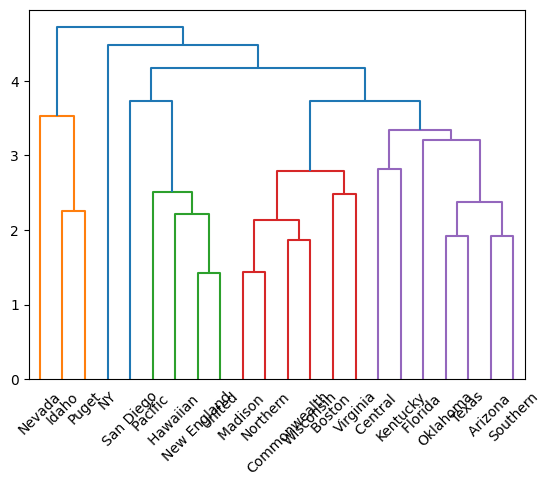

In [ ]:
# in linkage() set argument method = ’single’, ’complete’, ’average’, ’weighted’, centroid’, ’median’, ’ward’
Z = linkage(utilities_df_norm, method='average')
dendrogram(Z, labels=utilities_df_norm.index, color_threshold=3.6)

K means clustering

In [ ]:
# Load and preprocess data
utilities_df = pd.read_csv(file_name)
utilities_df.set_index('Company', inplace=True)
utilities_df = utilities_df.apply(lambda x: x.astype('float64'))

In [ ]:
# Normalize distances
utilities_df_norm = utilities_df.apply(preprocessing.scale, axis=0)
kmeans = KMeans(n_clusters=6, random_state=0).fit(utilities_df_norm)

In [ ]:
# Cluster membership
memb = pd.Series(kmeans.labels_, index=utilities_df_norm.index)
for key, item in memb.groupby(memb):
    print(key, ': ', ', '.join(item.index))

0 :  Commonwealth, Madison , Northern, Wisconsin, Virginia
1 :  Pacific 
2 :  Arizona , Central , Florida , Oklahoma, Southern, Texas
3 :  Idaho, Nevada, Puget
4 :  Kentucky
5 :  Boston , NY, Hawaiian , New England, San Diego, United


<Axes: >

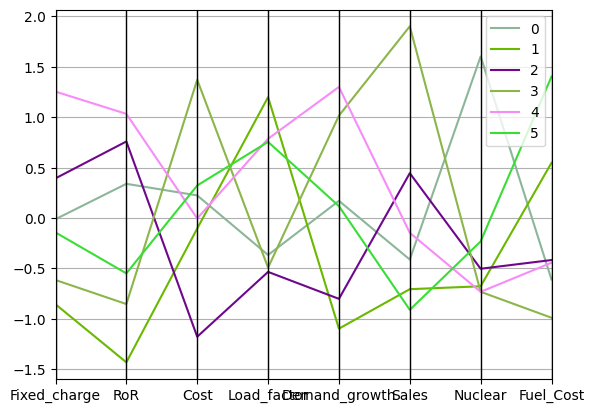

In [ ]:
# Visualize cluster centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=utilities_df_norm.columns)
centroids['Cluster'] = centroids.index
parallel_coordinates(centroids, 'Cluster')


In [ ]:
# Get cluster centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=utilities_df_norm.columns)

# Get squared distances
squared_distances = kmeans.transform(utilities_df_norm) ** 2

# Print cluster centroids and squared distances
print("Cluster Centroids:")
print(centroids)
print("\nSquared Distances:")
print(pd.DataFrame(squared_distances, columns=[f"Cluster {i+1}" for i in range(6)], index=utilities_df_norm.index))


Cluster Centroids:
   Fixed_charge       RoR      Cost  Load_factor  Demand_growth     Sales  \
0     -0.011599  0.339180  0.224086    -0.366466       0.170386 -0.411331   
1     -0.854783 -1.430526 -0.103911     1.198264      -1.096618 -0.705245   
2      0.393352  0.758801 -1.176527    -0.533952      -0.801203  0.444577   
3     -0.614402 -0.852787  1.370418    -0.491890       1.015056  1.900210   
4      1.253178  1.032466 -0.004518     0.785285       1.299530 -0.146480   
5     -0.142884 -0.548714  0.322651     0.754694       0.117868 -0.909952   

    Nuclear  Fuel_Cost  
0  1.601868  -0.609460  
1 -0.676588   0.547149  
2 -0.502869  -0.416385  
3 -0.731447  -0.988493  
4 -0.731447  -0.443073  
5 -0.231625   1.401169  

Squared Distances:
              Cluster 1     Cluster 2  Cluster 3  Cluster 4  Cluster 5  \
Company                                                                  
Arizona        7.865991  7.046439e+00   3.664756   9.223795  11.091716   
Boston         5.966084 

In [ ]:
# if you encounter problem with plotting Elbow method, you can install the following package
!pip install --upgrade threadpoolctl==3.1.0

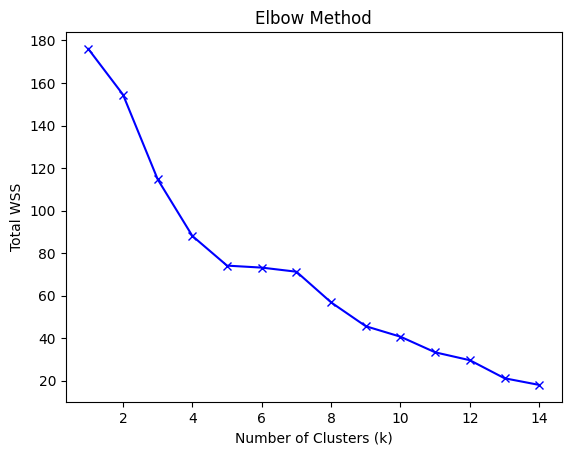

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


# Calculate WSS for different values of k
wss = []
k_values = range(1, 15)  # Change the range as per your requirement
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(utilities_df_norm)
    wss.append(kmeans.inertia_)

# Plot the WSS values
plt.plot(k_values, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Total WSS')
plt.title('Elbow Method')
plt.show()
